# **DECISION TREE**

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, confusion_matrix, r2_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

# **Decision Tree for Classification**

##**IRIS Dataset**

In [2]:
# Load the diabetes dataset
iris = datasets.load_iris()
iris_X, iris_y = iris.data, iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f"Kích thước dữ liệu: {iris_X.shape}")
print(f"Số lượng đặc trưng: {len(feature_names)}")
print(f"Tên các đặc trưng: {feature_names}")
print(f"Số lượng lớp: {len(target_names)}")
print(f"Tên các lớp: {target_names}")

Kích thước dữ liệu: (150, 4)
Số lượng đặc trưng: 4
Tên các đặc trưng: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Số lượng lớp: 3
Tên các lớp: ['setosa' 'versicolor' 'virginica']


In [3]:
iris_df = pd.DataFrame(iris_X, columns=feature_names)
iris_df['target'] = iris_y
iris_df['species'] = [target_names[i] for i in iris_y]
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


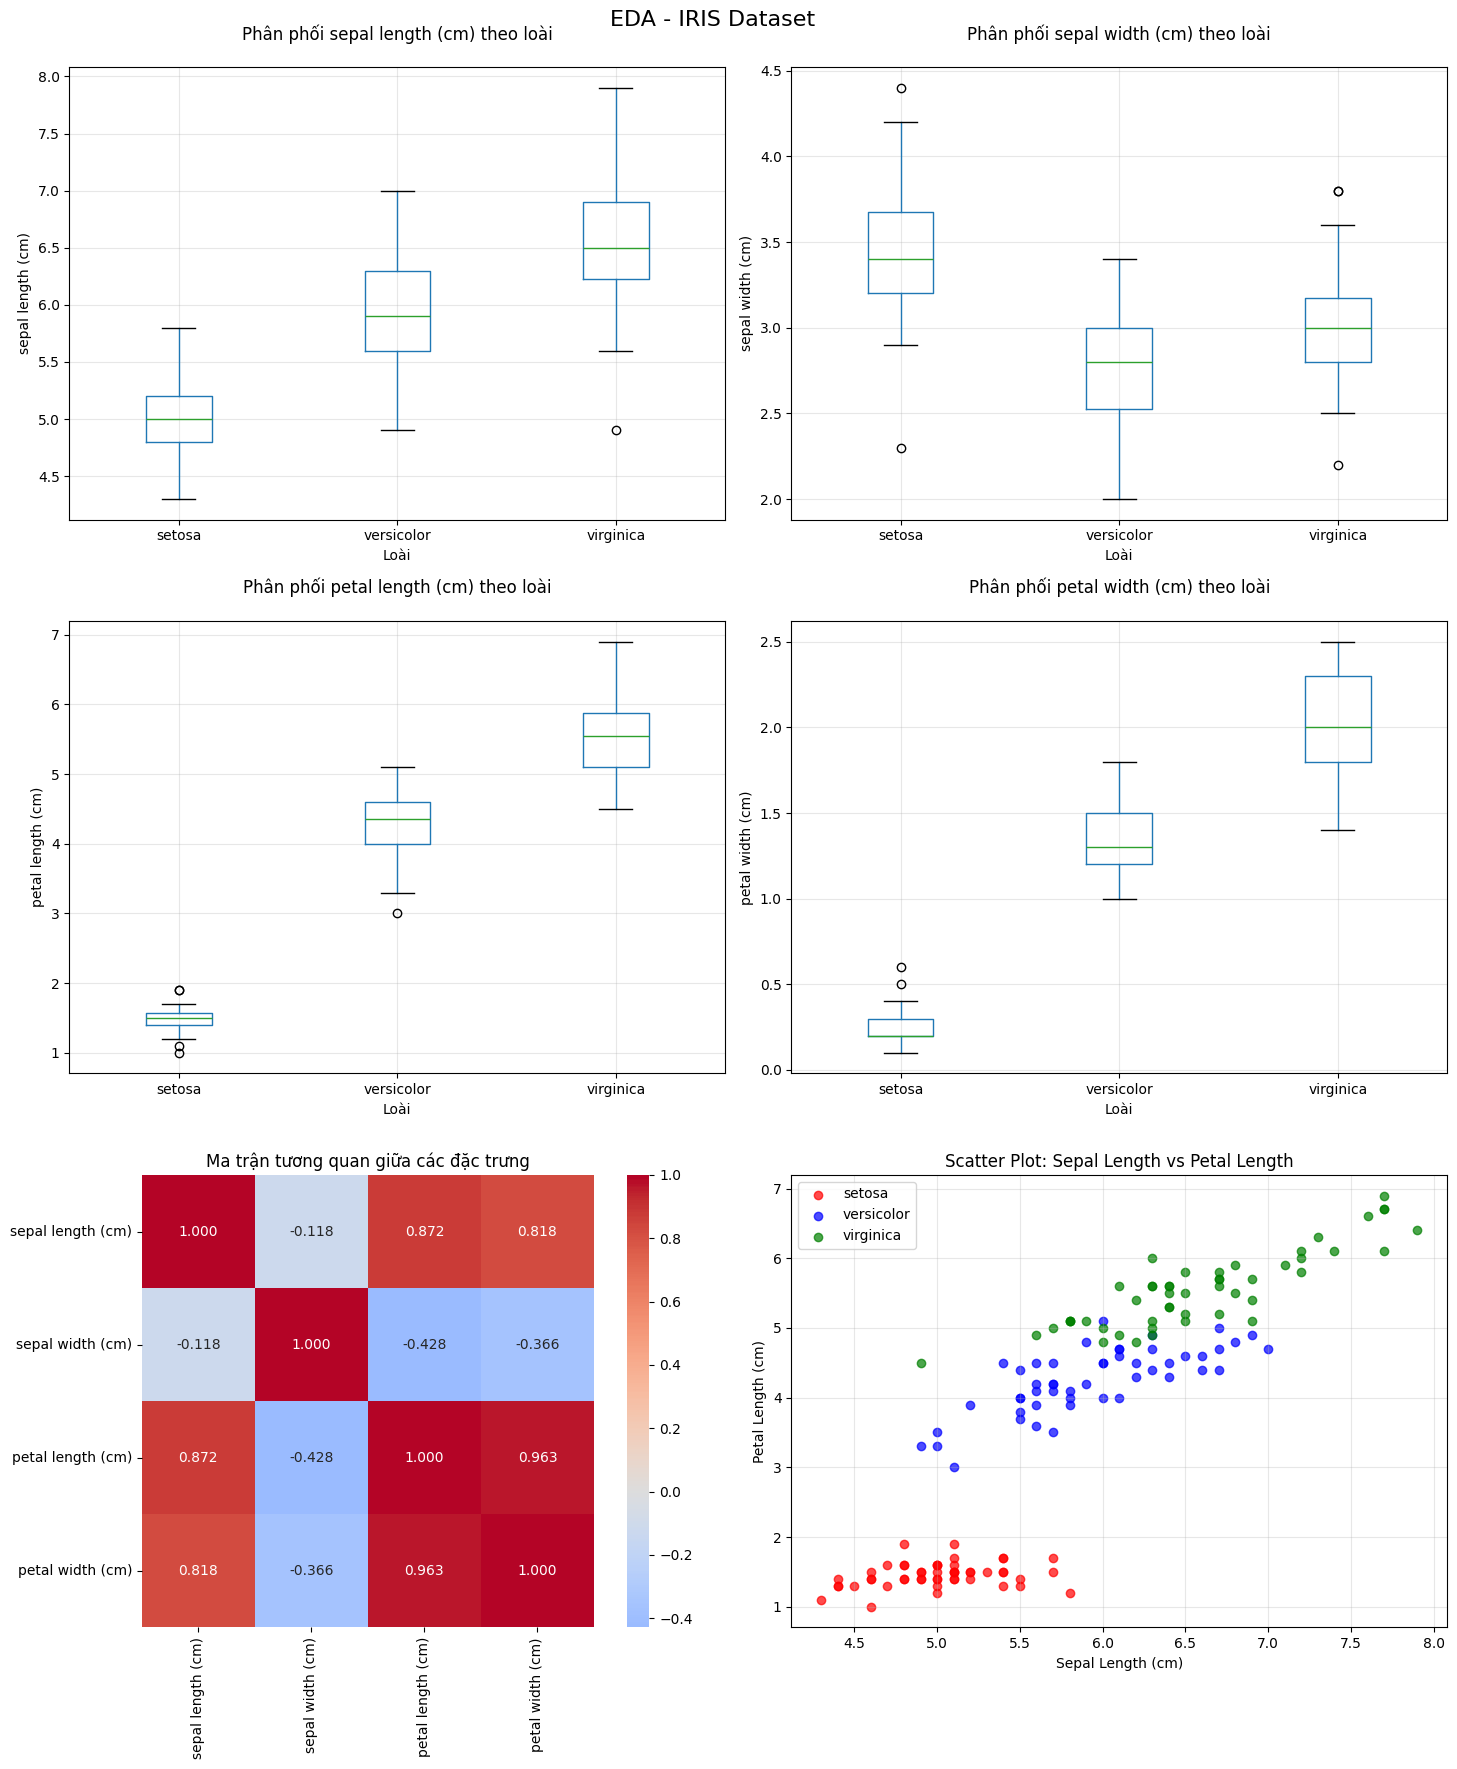

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# 1. Phân phối các đặc trưng theo loài
for i, feature in enumerate(feature_names):
    ax = axes[i//2, i%2]
    iris_df.boxplot(column=feature, by="species", ax=ax)
    ax.set_title(f"Phân phối {feature} theo loài", fontsize=12, pad=20)
    ax.set_xlabel("Loài", fontsize=10)
    ax.set_ylabel(feature, fontsize=10)
    ax.grid(True, alpha=0.3)

# 2. Ma trận tương quan
axes[2, 0].remove()
axes[2, 0] = plt.subplot(3, 2, 5)
correlation_matrix = iris_df[feature_names].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0,
           square=True, ax=axes[2, 0], fmt=".3f")
axes[2, 0].set_title("Ma trận tương quan giữa các đặc trưng", fontsize=12)

# 3. Scatter plot
axes[2, 1].remove()
axes[2, 1] = plt.subplot(3, 2, 6)
colors = ["red", "blue", "green"]
for i, species in enumerate(target_names):
    species_data = iris_df[iris_df["species"] == species]
    axes[2, 1].scatter(species_data["sepal length (cm)"],
                      species_data["petal length (cm)"],
                      label=species, alpha=0.7, color=colors[i])
axes[2, 1].set_xlabel("Sepal Length (cm)", fontsize=10)
axes[2, 1].set_ylabel("Petal Length (cm)", fontsize=10)
axes[2, 1].set_title("Scatter Plot: Sepal Length vs Petal Length", fontsize=12)
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.suptitle("EDA - IRIS Dataset", fontsize=16, y=0.98)
plt.tight_layout()
plt.savefig("01_EDA_IRIS.png", dpi=600, bbox_inches="tight")
plt.show()

In [9]:
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    iris_X, iris_y, test_size = 0.2, random_state = 3
)

print(f"Kích thước tập huấn luyện: {X_train_iris.shape}")
print(f"Kích thước tập kiểm tra: {X_test_iris.shape}")
print(f"Phân phối lớp trong tập huấn luyện: {np.bincount(y_train_iris)}")
print(f"Phân phối lớp trong tập kiểm tra: {np.bincount(y_test_iris)}")

Kích thước tập huấn luyện: (120, 4)
Kích thước tập kiểm tra: (30, 4)
Phân phối lớp trong tập huấn luyện: [40 40 40]
Phân phối lớp trong tập kiểm tra: [10 10 10]


In [10]:
# Áp dụng StandardScaler
scaler_iris = StandardScaler()
X_train_iris_scaled = scaler_iris.fit_transform(X_train_iris)
X_test_iris_scaled = scaler_iris.transform(X_test_iris)

In [16]:
# Xây dựng mô hình Decision Tree
dt_classifier = DecisionTreeClassifier(max_depth=5, min_samples_split=10)
dt_classifier.fit(X_train_iris, y_train_iris)

# Dự đoán
y_pred_iris = dt_classifier.predict(X_test_iris)

# Đánh giá
accuracy = accuracy_score(y_test_iris, y_pred_iris)
print(f"Độ chính xác: {accuracy:.4f}")

Độ chính xác: 0.9333


In [12]:
print(classification_report(y_test_iris, y_pred_iris, target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



[Text(0.3333333333333333, 0.9, 'Petal_Length <= 2.45\ngini = 0.667\nsamples = 120\nvalue = [40, 40, 40]'),
 Text(0.2222222222222222, 0.7, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.2777777777777778, 0.8, 'True  '),
 Text(0.4444444444444444, 0.7, 'Petal_Length <= 4.75\ngini = 0.5\nsamples = 80\nvalue = [0, 40, 40]'),
 Text(0.38888888888888884, 0.8, '  False'),
 Text(0.2222222222222222, 0.5, 'Petal_Width <= 1.65\ngini = 0.053\nsamples = 37\nvalue = [0, 36, 1]'),
 Text(0.1111111111111111, 0.3, 'gini = 0.0\nsamples = 36\nvalue = [0, 36, 0]'),
 Text(0.3333333333333333, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.6666666666666666, 0.5, 'Petal_Width <= 1.75\ngini = 0.169\nsamples = 43\nvalue = [0, 4, 39]'),
 Text(0.5555555555555556, 0.3, 'gini = 0.5\nsamples = 6\nvalue = [0, 3, 3]'),
 Text(0.7777777777777778, 0.3, 'Petal_Length <= 4.85\ngini = 0.053\nsamples = 37\nvalue = [0, 1, 36]'),
 Text(0.6666666666666666, 0.1, 'gini = 0.5\nsamples = 2\nvalue = [0, 1, 1]'),


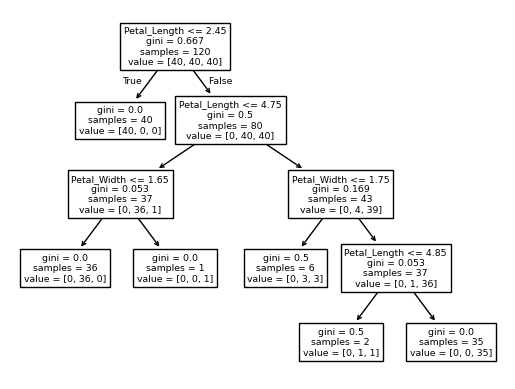

In [13]:
from sklearn.tree import plot_tree

# visualization
plot_tree(dt_classifier, feature_names=["Sepal_Length", "Sepal_Width", "Petal_Length", "Petal_Width"])

# **Decision Tree for Regreesion**

## **CPU Machine Dataset**

In [19]:
machine_cpu = fetch_openml(name='machine_cpu', version=1)
cpu_X, cpu_y = machine_cpu.data, machine_cpu.target
cpu_feature_names = machine_cpu.feature_names

In [20]:
print(machine_cpu.DESCR)

**Author**:   
**Source**: Unknown -   
**Please cite**:   

The problem concerns Relative CPU Performance Data. More information can be obtained in the UCI Machine
 Learning repository (http://www.ics.uci.edu/~mlearn/MLSummary.html).
 The used attributes are :
 MYCT: machine cycle time in nanoseconds (integer)
 MMIN: minimum main memory in kilobytes (integer)
 MMAX: maximum main memory in kilobytes (integer)
 CACH: cache memory in kilobytes (integer)
 CHMIN: minimum channels in units (integer)
 CHMAX: maximum channels in units (integer)
 PRP: published relative performance (integer) (target variable)
 
 Original source: UCI machine learning repository. 
 Source: collection of regression datasets by Luis Torgo (ltorgo@ncc.up.pt) at
 http://www.ncc.up.pt/~ltorgo/Regression/DataSets.html
 Characteristics: 209 cases; 6 continuous variables

Downloaded from openml.org.


In [21]:
cpu_df = pd.DataFrame(cpu_X, columns=cpu_feature_names)
cpu_df["performance"] = cpu_y

print(f"Kích thước dữ liệu: {cpu_df.shape}")
print(f"Các đặc trưng: {cpu_feature_names}")
print(f"Target: Performance (CPU Relative Performance)")

Kích thước dữ liệu: (209, 7)
Các đặc trưng: ['MYCT', 'MMIN', 'MMAX', 'CACH', 'CHMIN', 'CHMAX']
Target: Performance (CPU Relative Performance)


In [23]:
cpu_df

,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,performance
0,125,256,6000,256,16,128,198
1,29,8000,32000,32,8,32,269
2,29,8000,32000,32,8,32,220
3,29,8000,32000,32,8,32,172
4,29,8000,16000,32,8,16,132
...,...,...,...,...,...,...,...
204,124,1000,8000,0,1,8,42
205,98,1000,8000,32,2,8,46
206,125,2000,8000,0,2,14,52
207,480,512,8000,32,0,0,67


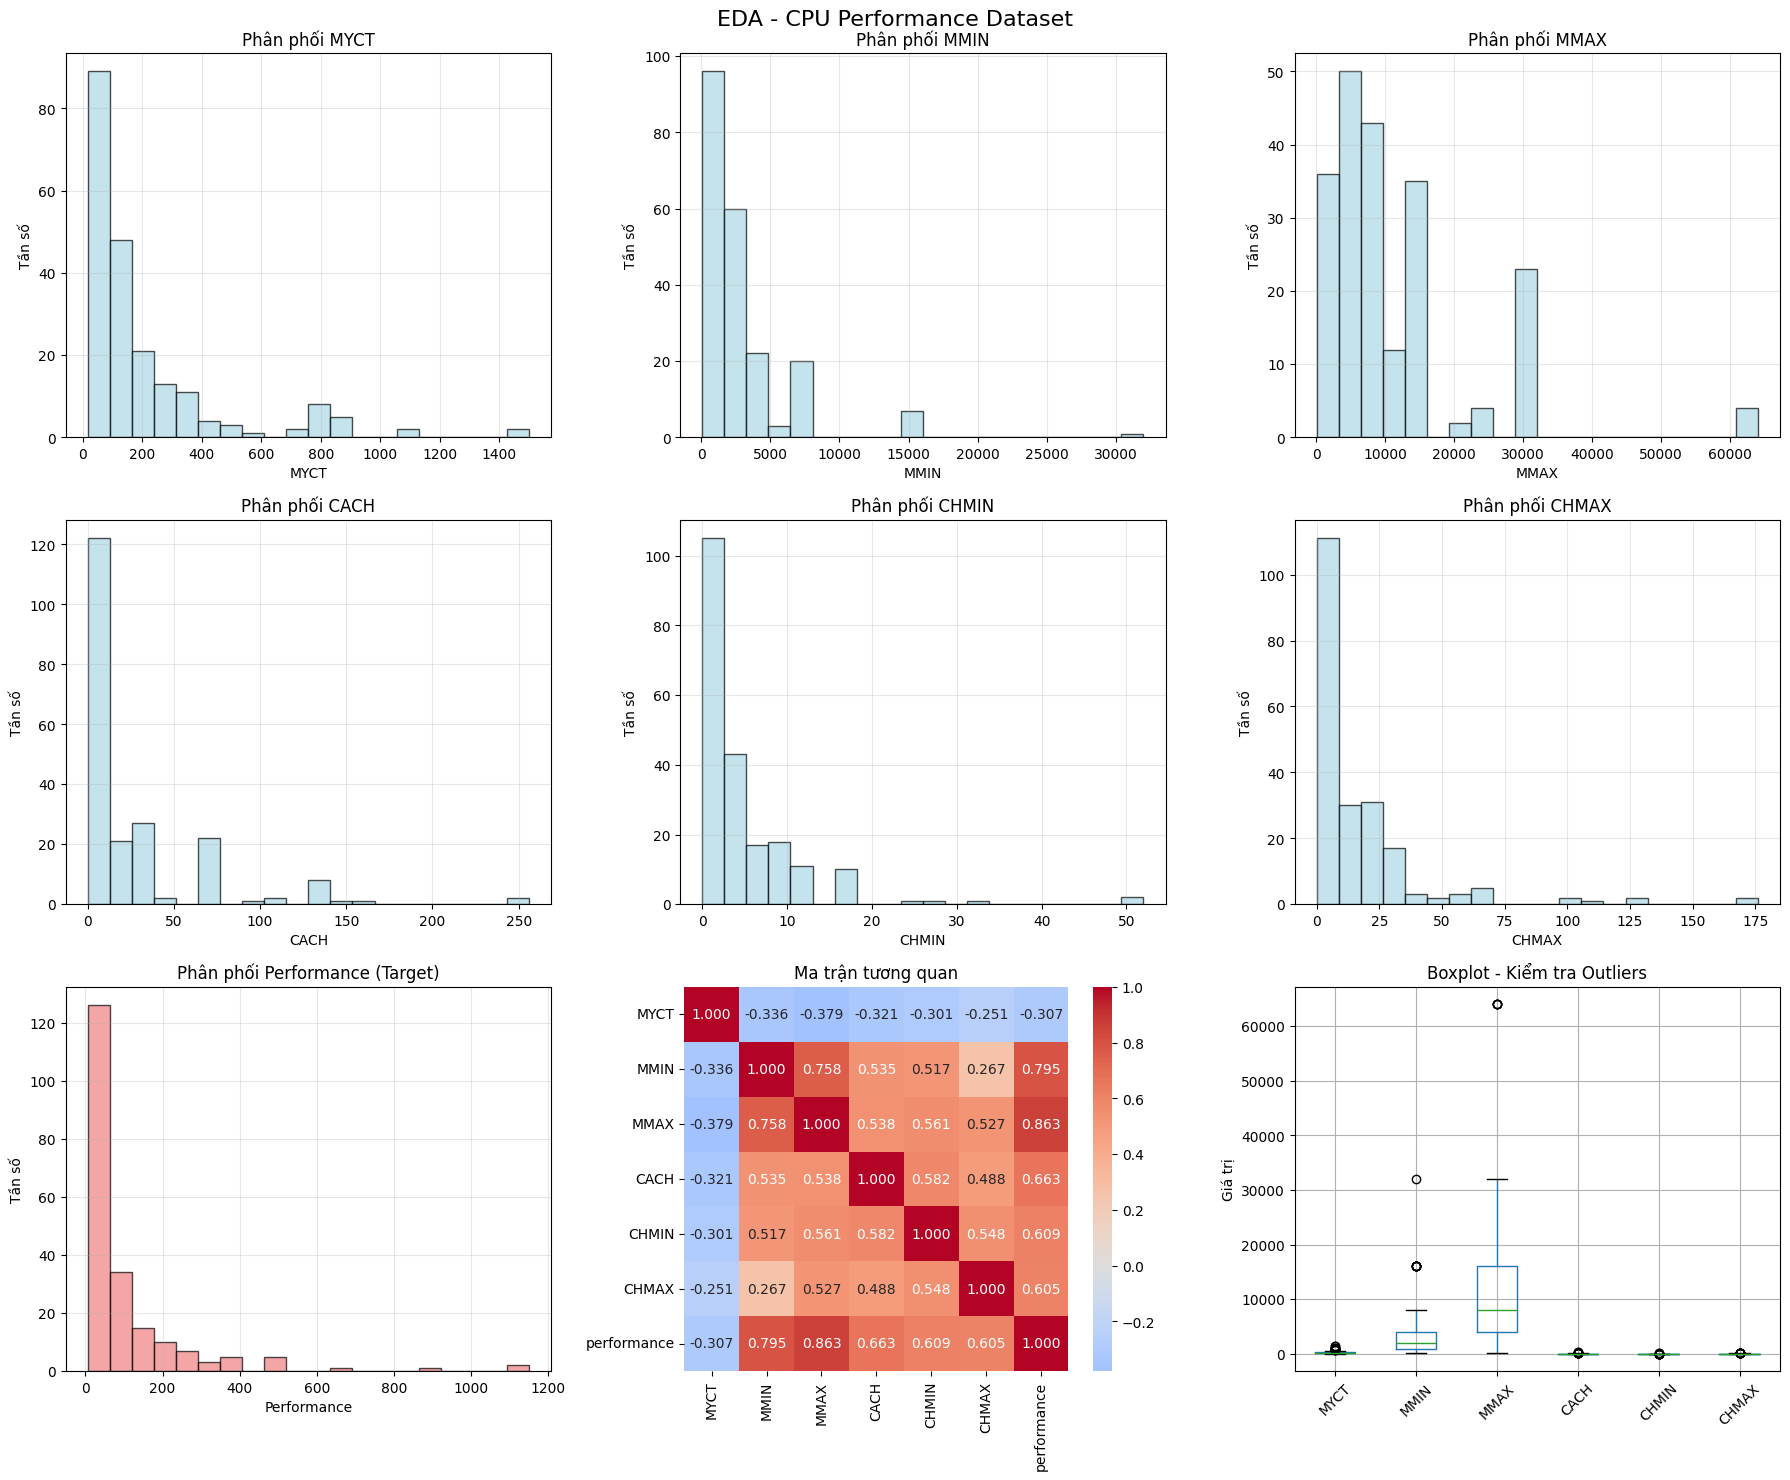

In [22]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# 1-6. Histogram của các đặc trưng
for i, col in enumerate(cpu_feature_names):
    axes[i].hist(cpu_df[col], bins=20, alpha=0.7, color="lightblue", edgecolor="black")
    axes[i].set_title(f"Phân phối {col}", fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Tần số", fontsize=10)
    axes[i].grid(True, alpha=0.3)

# 7. Histogram của target
axes[6].hist(cpu_df["performance"], bins=20, alpha=0.7, color="lightcoral", edgecolor="black")
axes[6].set_title("Phân phối Performance (Target)", fontsize=12)
axes[6].set_xlabel("Performance", fontsize=10)
axes[6].set_ylabel("Tần số", fontsize=10)
axes[6].grid(True, alpha=0.3)

# 8. Ma trận tương quan
correlation_matrix_cpu = cpu_df[cpu_feature_names + ["performance"]].corr()
sns.heatmap(correlation_matrix_cpu, annot=True, cmap="coolwarm", center=0,
           square=True, ax=axes[7], fmt=".3f")
axes[7].set_title("Ma trận tương quan", fontsize=12)

# 9. Boxplot để kiểm tra outliers
cpu_df.boxplot(column=cpu_feature_names, ax=axes[8])
axes[8].set_title("Boxplot - Kiểm tra Outliers", fontsize=12)
axes[8].set_ylabel("Giá trị", fontsize=10)
axes[8].tick_params(axis="x", rotation=45)

plt.suptitle("EDA - CPU Performance Dataset", fontsize=16, y=0.98)
plt.tight_layout()
plt.savefig("02_EDA_CPU.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
# Chia dữ liệu
X_train_cpu, X_test_cpu, y_train_cpu, y_test_cpu = train_test_split(
    cpu_df.iloc[:,:-1], cpu_df.iloc[:,-1]
)

In [27]:
scaler_cpu = StandardScaler()
X_train_cpu_scaled = scaler_cpu.fit_transform(X_train_cpu)
X_test_cpu_scaled = scaler_cpu.transform(X_test_cpu)

In [28]:
# Xây dựng mô hình Decision Tree Regression
dt_regressor = DecisionTreeRegressor(max_depth=5)
dt_regressor.fit(X_train_cpu, y_train_cpu)

# Dự đoán
y_pred_cpu = dt_regressor.predict(X_test_cpu)

# Đánh giá
mse = mean_squared_error(y_test_cpu, y_pred_cpu)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_test_cpu - y_pred_cpu))
r2 = r2_score(y_test_cpu, y_pred_cpu)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

MSE: 7565.2371
RMSE: 86.9784
MAE: 38.1582
R²: 0.7656


[Text(0.5833333333333334, 0.9166666666666666, 'MMAX <= 28000.0\nsquared_error = 23235.61\nsamples = 156\nvalue = 97.109'),
 Text(0.3125, 0.75, 'CACH <= 27.0\nsquared_error = 2905.04\nsamples = 138\nvalue = 56.413'),
 Text(0.4479166666666667, 0.8333333333333333, 'True  '),
 Text(0.20833333333333334, 0.5833333333333334, 'MMAX <= 6100.0\nsquared_error = 694.007\nsamples = 109\nvalue = 38.651'),
 Text(0.1111111111111111, 0.4166666666666667, 'CHMAX <= 4.5\nsquared_error = 173.67\nsamples = 62\nvalue = 26.323'),
 Text(0.05555555555555555, 0.25, 'MMAX <= 1750.0\nsquared_error = 167.225\nsamples = 26\nvalue = 19.923'),
 Text(0.027777777777777776, 0.08333333333333333, 'squared_error = 12.234\nsamples = 8\nvalue = 10.375'),
 Text(0.08333333333333333, 0.08333333333333333, 'squared_error = 177.583\nsamples = 18\nvalue = 24.167'),
 Text(0.16666666666666666, 0.25, 'MYCT <= 270.0\nsquared_error = 127.386\nsamples = 36\nvalue = 30.944'),
 Text(0.1388888888888889, 0.08333333333333333, 'squared_error = 

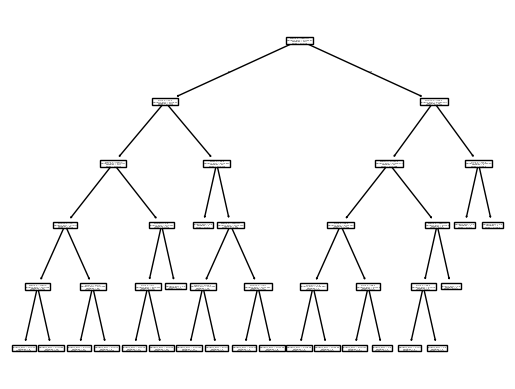

In [29]:
from sklearn.tree import plot_tree

plot_tree(dt_regressor, feature_names=['MYCT', 'MMIN', 'MMAX', 'CACH', 'CHMIN', 'CHMAX'])